In [103]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [104]:
#Loading the dataset
airb = pd.read_csv("Airbnb_site_hotel new.csv")
airb

,id,name,host_id,host_name,city,price,reply time,guest favourite,host since,host Certification,...,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales,area
0,1,Beautiful Victorian Home,1368256,Robert,Toronto,250,0.0,0,4563,1.0,...,47,6,"1,5",2,3,1,"0,9","0,42",102,North America
1,2,"World Class @ CN Tower, convention centre, The...",113345,Adela,Toronto,152,0.0,0,5120,1.0,...,42,4,1,1,2,5,"0,9","0,42",166,North America
2,3,Furnished room in lovely Annex house June -Oct31,1466410,Susan,Toronto,120,0.0,0,4534,1.0,...,0,1,1,1,2,2,1,"0,65",181,North America
3,4,Executive Studio Unit- Ideal for One Person,118124,Brent,Toronto,75,1.0,1,5111,1.0,...,29,1,1,0,1,1,1,1,365,North America
4,5,"Bright Beaches Apt, close to everything",175687,John,Toronto,90,0.0,0,5033,1.0,...,7,2,1,1,1,4,1,"0,8",328,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86181,86182,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"87,5",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",273,Asia
86182,86183,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,330402207,葦靜,taipei,25,1.0,0,1559,1.0,...,0,1,0,0,1,34,1,"0,88",96,Asia
86183,86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"89,28125",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",274,Asia
86184,86185,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"100,90625",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",274,Asia


In [105]:
airb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86186 entries, 0 to 86185
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         86186 non-null  int64  
 1   name                       86186 non-null  object 
 2   host_id                    86186 non-null  int64  
 3   host_name                  86186 non-null  object 
 4   city                       86186 non-null  object 
 5   price                      80762 non-null  object 
 6   reply time                 66867 non-null  float64
 7   guest favourite            86186 non-null  int64  
 8   host since                 86186 non-null  int64  
 9   host Certification         82903 non-null  float64
 10  room_type                  86186 non-null  int64  
 11  host total listings count  86186 non-null  int64  
 12  consumer                   35421 non-null  object 
 13  total reviewers number     86186 non-null  int

In [106]:
airb.describe()

,id,host_id,reply time,guest favourite,host since,host Certification,room_type,host total listings count,total reviewers number,accommodates,bedrooms,beds,listing number,sales
count,86186.000000,8.618600e+04,66867.000000,86186.000000,86186.000000,82903.0,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000
mean,43093.500000,1.959076e+08,0.769857,0.273304,2380.740236,1.0,2.663959,23.492737,36.414174,3.412747,1.247407,1.914441,45.196772,183.385086
std,24879.899487,1.849803e+08,0.420928,0.445658,1269.305372,0.0,0.524877,73.067586,75.989911,2.393287,1.093598,1.732507,258.312637,119.302210
min,1.000000,1.581000e+03,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,21547.250000,2.890381e+07,1.000000,0.000000,1422.000000,1.0,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,80.000000
50%,43093.500000,1.308280e+08,1.000000,0.000000,2540.000000,1.0,3.000000,3.000000,9.000000,2.000000,1.000000,1.000000,3.000000,193.000000
75%,64639.750000,3.492982e+08,1.000000,1.000000,3337.000000,1.0,3.000000,12.000000,37.000000,4.000000,2.000000,2.000000,15.000000,287.000000
max,86186.000000,5.752345e+08,1.000000,1.000000,5745.000000,1.0,4.000000,837.000000,2575.000000,16.000000,21.000000,60.000000,4818.000000,365.000000


In [107]:
airb.dtypes

id                             int64
name                          object
host_id                        int64
host_name                     object
city                          object
price                         object
reply time                   float64
guest favourite                int64
host since                     int64
host Certification           float64
room_type                      int64
host total listings count      int64
consumer                      object
total reviewers number         int64
accommodates                   int64
bathrooms                     object
bedrooms                       int64
beds                           int64
listing number                 int64
host response rate            object
host acceptance rate          object
sales                          int64
area                          object
dtype: object

## Checking for duplicated values

In [108]:
airb.duplicated().sum()

np.int64(0)

## Splitting the dataset into cont and cat data

In [109]:
cont_data =airb.select_dtypes(include=['float64','int64'])
cont_data

,id,host_id,reply time,guest favourite,host since,host Certification,room_type,host total listings count,total reviewers number,accommodates,bedrooms,beds,listing number,sales
0,1,1368256,0.0,0,4563,1.0,3,1,47,6,2,3,1,102
1,2,113345,0.0,0,5120,1.0,3,5,42,4,1,2,5,166
2,3,1466410,0.0,0,4534,1.0,2,1,0,1,1,2,2,181
3,4,118124,1.0,1,5111,1.0,3,1,29,1,0,1,1,365
4,5,175687,0.0,0,5033,1.0,3,1,7,2,1,1,4,328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86181,86182,413599737,1.0,0,1018,1.0,3,13,0,2,0,1,56,273
86182,86183,330402207,1.0,0,1559,1.0,1,2,0,1,0,1,34,96
86183,86184,413599737,1.0,0,1018,1.0,3,13,0,2,0,1,56,274
86184,86185,413599737,1.0,0,1018,1.0,3,13,0,2,0,1,56,274


In [110]:
cat_data = airb.select_dtypes(include=['object'])
cat_data

,name,host_name,city,price,consumer,bathrooms,host response rate,host acceptance rate,area
0,Beautiful Victorian Home,Robert,Toronto,250,"6,81","1,5","0,9","0,42",North America
1,"World Class @ CN Tower, convention centre, The...",Adela,Toronto,152,"6,67",1,"0,9","0,42",North America
2,Furnished room in lovely Annex house June -Oct31,Susan,Toronto,120,0,1,1,"0,65",North America
3,Executive Studio Unit- Ideal for One Person,Brent,Toronto,75,"6,86",1,1,1,North America
4,"Bright Beaches Apt, close to everything",John,Toronto,90,"6,57",1,1,"0,8",North America
...,...,...,...,...,...,...,...,...,...
86181,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,"87,5",NaN,0,"0,99","0,99",Asia
86182,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,葦靜,taipei,25,NaN,0,1,"0,88",Asia
86183,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,"89,28125",NaN,0,"0,99","0,99",Asia
86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,"100,90625",NaN,0,"0,99","0,99",Asia


## converting price into a float

In [111]:
airb['price'] = airb['price'].str.replace(',','').str.replace('$','').str.strip()
airb['price'] = airb['price'].astype(float)

In [112]:
airb['consumer'] = airb['consumer'].str.replace(',','').str.strip()
airb['consumer'] = airb['consumer'].astype(float)

In [113]:
airb['bathrooms'] = airb['bathrooms'].str.replace(',','').str.strip()
airb['bathrooms'] = airb['bathrooms'].astype(float)

In [114]:
airb['host response rate'] = airb['host response rate'].str.replace(',','').str.strip()
airb['host response rate'] = airb['host response rate'].astype(float)

In [115]:
airb['host acceptance rate'] = airb['host acceptance rate'].str.replace(',','').str.strip()
airb['host acceptance rate'] = airb['host acceptance rate'].astype(float)

In [116]:
cat =airb.select_dtypes(include=['object'])
cat

,name,host_name,city,area
0,Beautiful Victorian Home,Robert,Toronto,North America
1,"World Class @ CN Tower, convention centre, The...",Adela,Toronto,North America
2,Furnished room in lovely Annex house June -Oct31,Susan,Toronto,North America
3,Executive Studio Unit- Ideal for One Person,Brent,Toronto,North America
4,"Bright Beaches Apt, close to everything",John,Toronto,North America
...,...,...,...,...
86181,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia
86182,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,葦靜,taipei,Asia
86183,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia
86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia


In [117]:
cont = airb.select_dtypes(exclude=['object'])

 ## Imputing for missing values

In [118]:
airb.isnull().sum()

id                               0
name                             0
host_id                          0
host_name                        0
city                             0
price                        38192
reply time                   19319
guest favourite                  0
host since                       0
host Certification            3283
room_type                        0
host total listings count        0
consumer                     50765
total reviewers number           0
accommodates                     0
bathrooms                        0
bedrooms                         0
beds                             0
listing number                   0
host response rate               0
host acceptance rate             0
sales                            0
area                             0
dtype: int64

In [119]:
airb['host Certification'].describe()

count    82903.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: host Certification, dtype: float64

In [120]:
## computing for missing values of host Certification
airb['host Certification'] = airb['host Certification'].fillna(airb['host Certification'].mean())

In [121]:
airb['reply time'].describe()

count    66867.000000
mean         0.769857
std          0.420928
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: reply time, dtype: float64

In [122]:
airb['reply time'] = airb['reply time'].fillna(airb['reply time'].median())

- Since price and consumer have high number of missing values, we would've just deleted them but they may be important columns so we are going to impute for them using iterative imputer.
- A iterative imputer works in this way: each column that has missing values is regressed on other features and so the missing values are predicted until the model stabilizes.

In [123]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

num_cols= airb.select_dtypes(include=[np.number]).columns
imputer = IterativeImputer(max_iter=10, random_state=42)

airb[num_cols]= imputer.fit_transform(airb[num_cols])

In [124]:
airb['price'].unique()

array([8.80248054e+08, 8.78528671e+08, 8.80382541e+08, ...,
       1.20843750e+07, 1.48218750e+07, 2.42031250e+07])

In [125]:
airb['price'].describe()

count    8.618600e+04
mean     1.146795e+09
std      1.678961e+09
min      9.000000e+00
25%      3.162500e+02
50%      9.115079e+08
75%      1.364717e+09
max      9.991975e+09
Name: price, dtype: float64

In [126]:
airb.isnull().sum()

id                           0
name                         0
host_id                      0
host_name                    0
city                         0
price                        0
reply time                   0
guest favourite              0
host since                   0
host Certification           0
room_type                    0
host total listings count    0
consumer                     0
total reviewers number       0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
listing number               0
host response rate           0
host acceptance rate         0
sales                        0
area                         0
dtype: int64

# Vusualizing the distribution

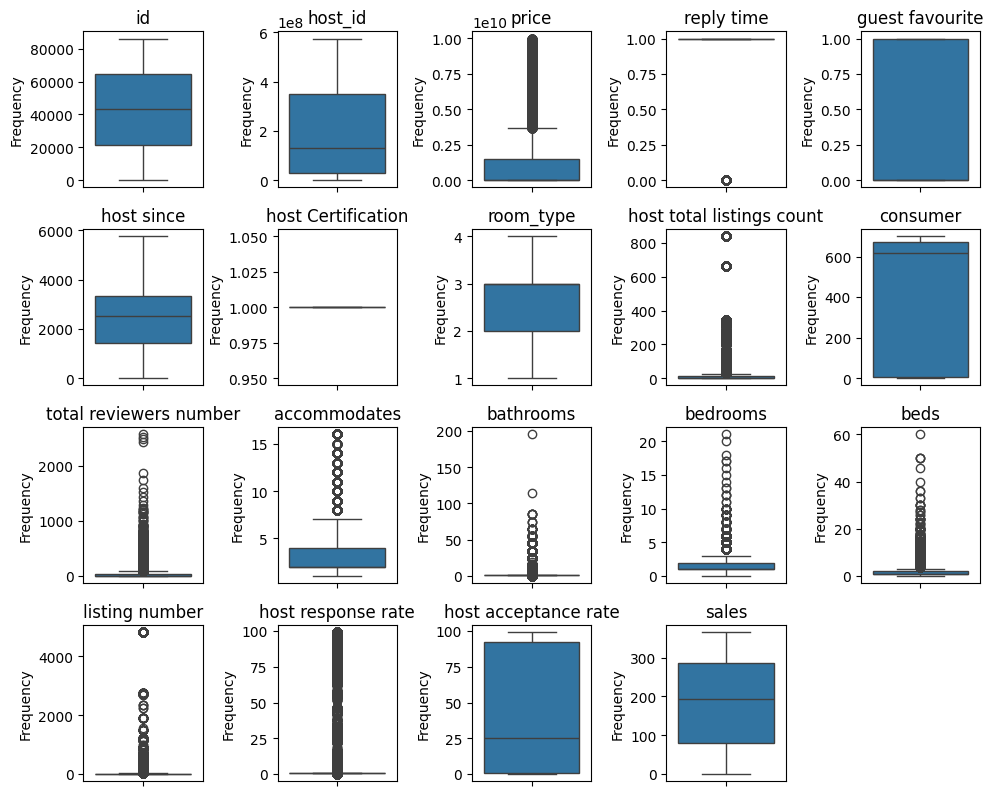

In [127]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cont.columns):
    plt.subplot(5,5, i+1)
    sns.boxplot(cont[col])
    plt.title(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Removing outliers

In [128]:
def remove_outliers(columns):
    for column in columns:
        Q1 = cont[column].quantile(0.25)
        Q3 = cont[column].quantile(0.75)

        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR

        cont[column] = np.where(cont[column]> upper_bound, upper_bound,cont[column])
        cont[column] = np.where(cont[column]< lower_bound, lower_bound,cont[column])

In [129]:
remove_outliers(cont)

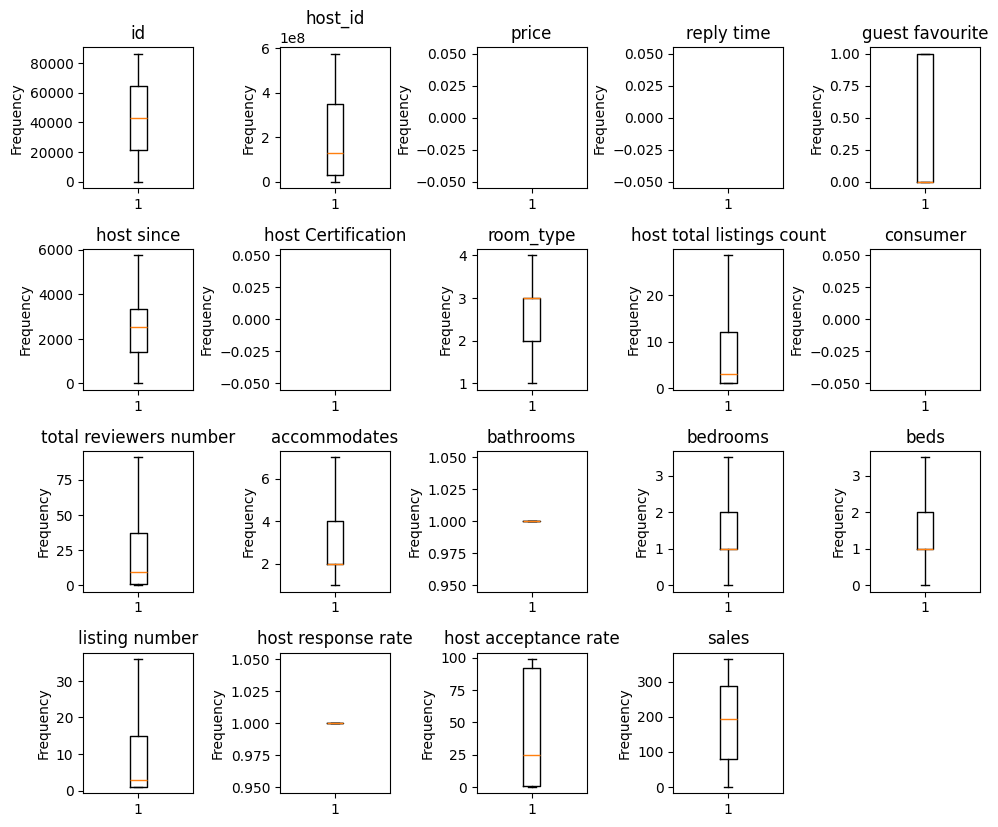

In [130]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cont.columns):
    plt.subplot(5,5, i+1)
    plt.boxplot(cont[col])
    plt.title(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [131]:
corr_matrix = cont.corr()
corr_matrix

,id,host_id,price,reply time,guest favourite,host since,host Certification,room_type,host total listings count,consumer,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales
id,1.000000,0.098421,0.163372,NaN,0.018683,-0.120604,NaN,0.100252,0.226733,-0.003711,-0.017943,0.180928,NaN,-0.130417,0.190206,0.213825,NaN,0.033723,0.095562
host_id,0.098421,1.000000,0.117867,NaN,0.006774,-0.970629,NaN,-0.009412,0.069169,-0.089183,-0.191749,0.045462,NaN,-0.002236,0.010878,0.059196,NaN,0.018849,-0.046873
price,0.163372,0.117867,1.000000,NaN,0.029934,-0.120467,NaN,-0.070605,0.214543,-0.161712,0.031080,-0.031440,NaN,0.094426,-0.029877,0.196289,NaN,0.022609,-0.055879
reply time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guest favourite,0.018683,0.006774,0.029934,NaN,1.000000,-0.009381,NaN,0.053940,-0.097683,0.211021,0.194691,0.073780,NaN,0.057952,0.057313,-0.098524,NaN,0.087206,0.115908
host since,-0.120604,-0.970629,-0.120467,NaN,-0.009381,1.000000,NaN,0.008270,-0.070308,0.082319,0.184154,-0.047453,NaN,0.013001,-0.012310,-0.061502,NaN,-0.011624,0.038532
host Certification,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,0.100252,-0.009412,-0.070605,NaN,0.053940,0.008270,NaN,1.000000,-0.032954,0.071475,0.032924,0.424863,NaN,0.209884,0.275395,-0.022904,NaN,-0.006061,0.099216
host total listings count,0.226733,0.069169,0.214543,NaN,-0.097683,-0.070308,NaN,-0.032954,1.000000,-0.165185,-0.186605,-0.037556,NaN,-0.088980,0.000144,0.966442,NaN,0.191850,-0.181614
consumer,-0.003711,-0.089183,-0.161712,NaN,0.211021,0.082319,NaN,0.071475,-0.165185,1.000000,0.580937,0.019161,NaN,-0.064560,0.046851,-0.168402,NaN,0.115732,0.119956


In [132]:
target = airb['price']

In [133]:
cont_cols = ['consumer', 'total reviewers number', 'accommodates',
             'bathrooms', 'bedrooms', 'beds', 'host acceptance rate','sales']

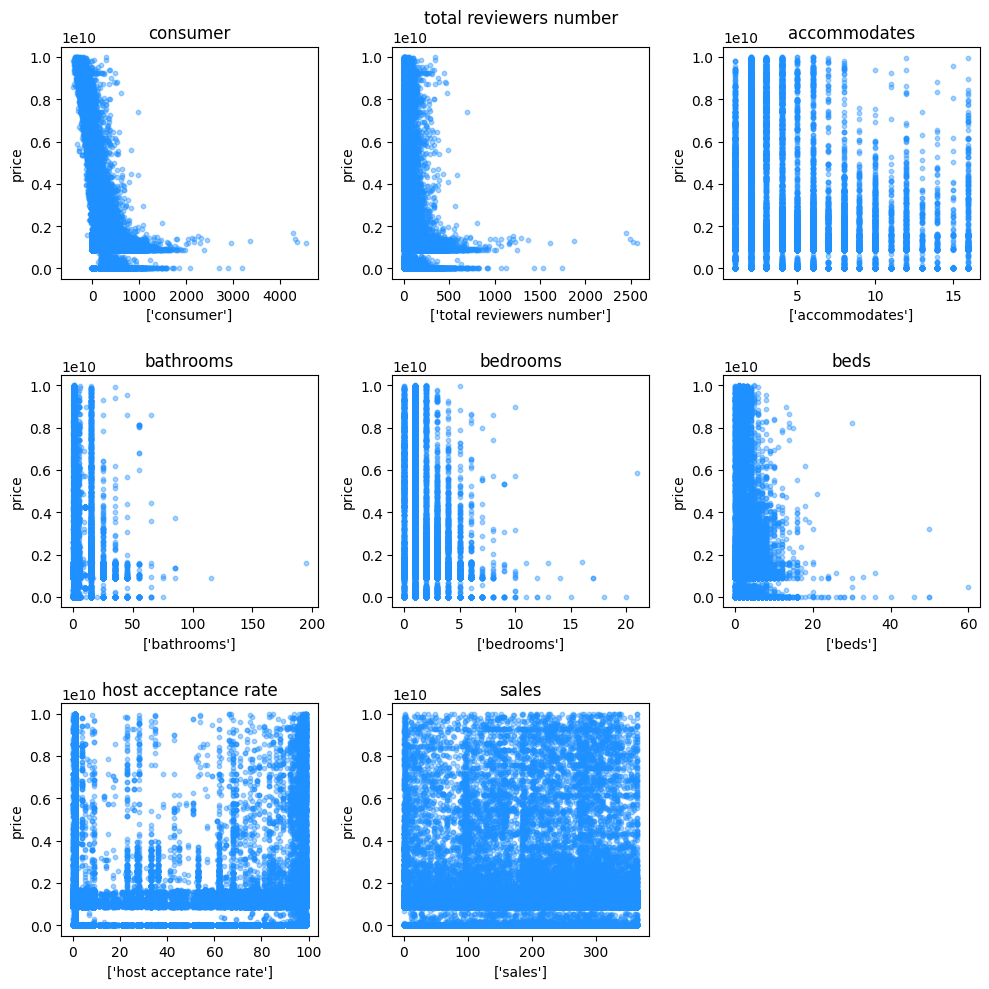

In [134]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cont_cols,1):
    plt.subplot(3,3,i)
    plt.scatter(airb[col], airb['price'], alpha=0.4, s=10, color='dodgerblue')
    plt.title(col)
    plt.ylabel("price")
    plt.xlabel([col])
plt.tight_layout()
plt.show()

- The above visualization shows the correlation between continous variables and the target variable

In [135]:
cat

,name,host_name,city,area
0,Beautiful Victorian Home,Robert,Toronto,North America
1,"World Class @ CN Tower, convention centre, The...",Adela,Toronto,North America
2,Furnished room in lovely Annex house June -Oct31,Susan,Toronto,North America
3,Executive Studio Unit- Ideal for One Person,Brent,Toronto,North America
4,"Bright Beaches Apt, close to everything",John,Toronto,North America
...,...,...,...,...
86181,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia
86182,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,葦靜,taipei,Asia
86183,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia
86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia


In [136]:
from scipy.stats import pearsonr, spearmanr, f_oneway
import seaborn as sns

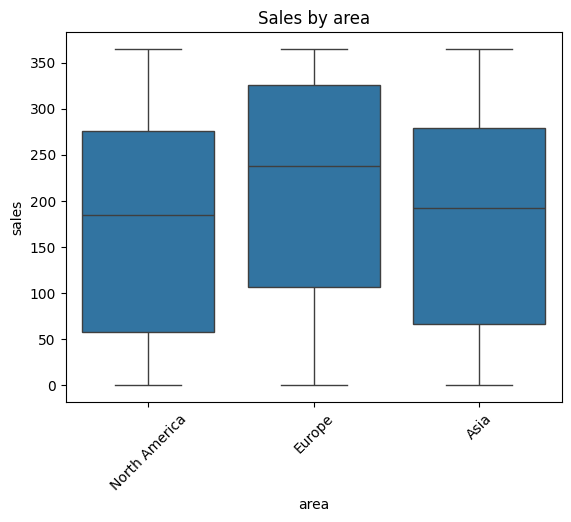

In [137]:
sns.boxplot(data=airb, x='area', y='sales')
plt.title('Sales by area')
plt.xticks(rotation=45)
plt.show()

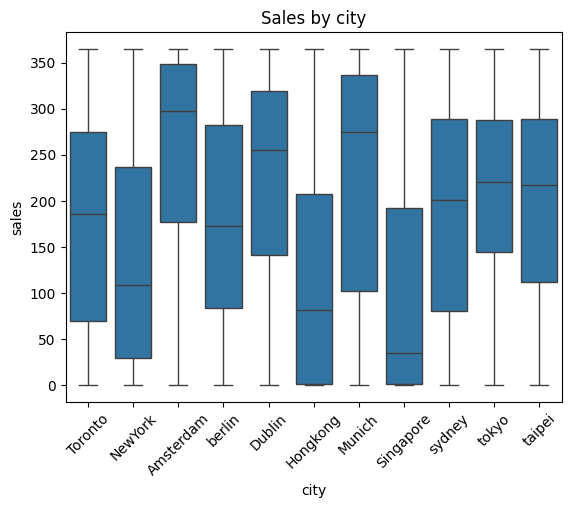

In [138]:
sns.boxplot(data=airb, x='city', y='sales')
plt.title('Sales by city')
plt.xticks(rotation=45)
plt.show()

In [139]:
def Anova_test(data, var1, var2):
    group_data=[
        group[var1].values for _, group in data.groupby(var2)
    ]
    f_stats, p_value = f_oneway(*group_data)
    if p_value > 0.05:
        print(f"{var1} is not significantly correlated with {var2}")
    else:
        print(f"{var1} is significantly correlated with [var2]")
    print(p_value)
    print(f_stats)


In [163]:
Anova_test(airb,"price","area")


price is significantly correlated with [var2]
0.0
9005.14755710783


In [164]:
Anova_test(airb,"price","city")

price is significantly correlated with [var2]
0.0
7173.619833348872


In [165]:
Anova_test(airb,"price","host_name")

price is significantly correlated with [var2]
0.0
4.553236453975047


In [166]:
Anova_test(airb,"price","name")

price is significantly correlated with [var2]
0.0
6.163659184211917


## Encoding the categorical variables

In [144]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error


# Target encoding

- calculates the mean of the target variable within each group and assigns the mean back to all rows belonging to that category

In [145]:
airb['city_encoded'] = airb.groupby('city')['sales'].transform('mean')
airb['area_encoded'] = airb.groupby('area')['sales'].transform('mean')
airb['name_encoded'] = airb.groupby('name')['sales'].transform('mean')
airb['hostname_encoded'] = airb.groupby('host_name')['sales'].transform('mean')

## Regression models

In [146]:
X = airb[['city_encoded','area_encoded','name_encoded','price', 'consumer', 'total reviewers number', 'accommodates',
             'bathrooms', 'bedrooms', 'beds', 'host acceptance rate']]
y= target

- Splitting the data into train and test sets

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((68948, 11), (17238, 11))

# Linear regression

In [148]:
x_linear = X[['city_encoded']]
y = target

In [149]:
X_train, X_test, y_train, y_test = train_test_split(x_linear,y,test_size=0.2, random_state=42)

In [150]:
linear_reg = LinearRegression()
linear_reg.fit(X_train,y_train)

LinearRegression()

- making predictions

In [151]:
y_pred = linear_reg.predict(X_test)

- Evaluating the model 

In [152]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}, \nMSE: {mse:.3f}, \nR^2: {r2:.3f}")

MAE: 967421064.336, 
MSE: 2698993918549414912.000, 
R^2: 0.005


- visualization of the linear regeression model perfomance

ValueError: x and y must be the same size

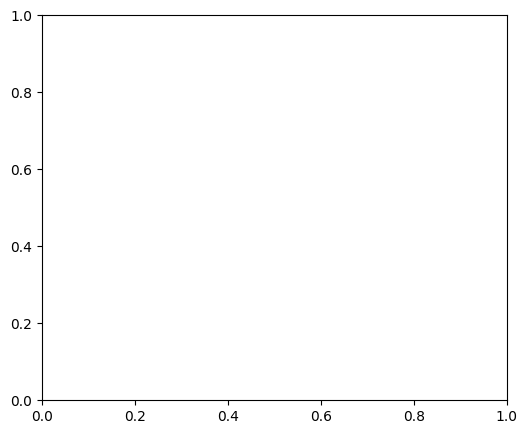

In [170]:
plt.figure(figsize=(6,5))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("City")
plt.ylabel("price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [154]:
X.corr()

,city_encoded,area_encoded,name_encoded,price,consumer,total reviewers number,accommodates,bathrooms,bedrooms,beds,host acceptance rate
city_encoded,1.000000,0.504061,0.338497,-0.076104,0.103371,0.106721,0.110457,0.109792,0.035516,0.097314,-0.011977
area_encoded,0.504061,1.000000,0.170194,-0.112464,0.121914,0.083401,-0.080362,0.015318,-0.115482,-0.017282,-0.037194
name_encoded,0.338497,0.170194,1.000000,-0.031659,0.146088,0.097195,0.038739,0.030809,0.002735,0.019434,0.036585
price,-0.076104,-0.112464,-0.031659,1.000000,-0.415796,-0.011685,-0.022788,0.013267,0.024497,-0.023312,0.019740
consumer,0.103371,0.121914,0.146088,-0.415796,1.000000,0.526369,0.037425,-0.030251,-0.052750,0.058536,0.112656
total reviewers number,0.106721,0.083401,0.097195,-0.011685,0.526369,1.000000,0.017622,-0.001100,-0.020768,0.041390,0.031270
accommodates,0.110457,-0.080362,0.038739,-0.022788,0.037425,0.017622,1.000000,0.236417,0.585003,0.720641,-0.008640
bathrooms,0.109792,0.015318,0.030809,0.013267,-0.030251,-0.001100,0.236417,1.000000,0.380192,0.200095,-0.026959
bedrooms,0.035516,-0.115482,0.002735,0.024497,-0.052750,-0.020768,0.585003,0.380192,1.000000,0.477467,-0.037873
beds,0.097314,-0.017282,0.019434,-0.023312,0.058536,0.041390,0.720641,0.200095,0.477467,1.000000,-0.005656


# Multiple Linear regeression

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [156]:
linear_reg_multi = LinearRegression()
linear_reg_multi.fit(X_train_scaled, y_train)

## making predictions
y_pred_multi = linear_reg_multi.predict(X_test_scaled)

In [157]:
### model evaluation
mae_m = mean_absolute_error(y_test, y_pred_multi)
mse_m = mean_squared_error(y_test, y_pred_multi)
r2_m = r2_score(y_test, y_pred_multi)

print(f"\nMAE: {mae_m:.3f},\nMSE: {mse_m:.3f},\nR²: {r2_m:.3f}")


MAE: 0.000,
MSE: 0.000,
R²: 1.000


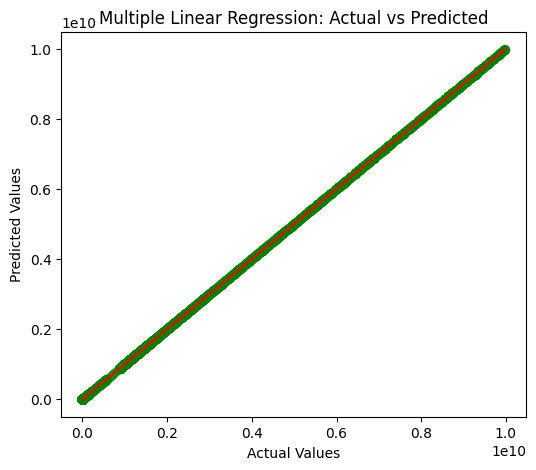

In [158]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_multi, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r-')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()

- the individual feature contributions to the predictions

In [159]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_reg_multi.coef_
}).sort_values("Coefficient", ascending=False)

coeffs

,Feature,Coefficient
3,price,1.686704e+09
1,area_encoded,3.278255e-07
5,total reviewers number,2.346933e-07
7,bathrooms,9.313226e-08
2,name_encoded,0.000000e+00
0,city_encoded,-7.158247e-08
8,bedrooms,-1.173466e-07
10,host acceptance rate,-1.634471e-07
9,beds,-2.216548e-07
6,accommodates,-6.593764e-07


## Decision tree regressor

In [160]:
tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train, y_train)
y_pred_tr = tree.predict(X_test)
mae_tr = mean_absolute_error(y_test, y_pred_tr)
mse_tr = mean_squared_error(y_test, y_pred_tr)
rmse_tr = root_mean_squared_error(y_test, y_pred_tr)
r2_tr = r2_score(y_test, y_pred_tr)
print(f'MAE: {mae_tr:.4f} \nMSE: {mse_tr:.4f} \nRMSE: {rmse_tr:.4f} \nR2: {r2_tr:.2f}') 

MAE: 19076998.0051 
MSE: 961293411709699.3750 
RMSE: 31004732.0858 
R2: 1.00


In [161]:
feature_names = X.columns

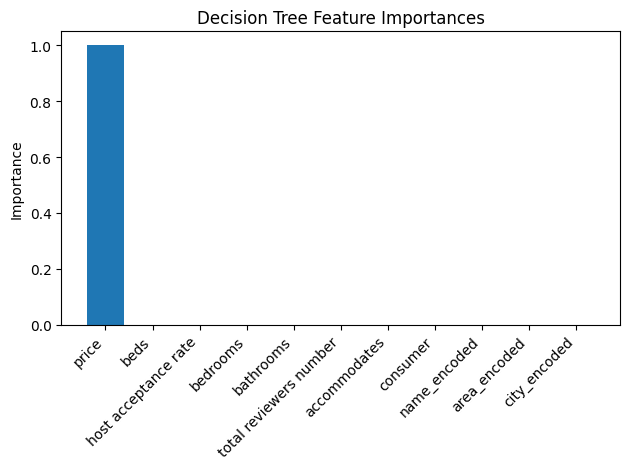

In [162]:
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure()
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()